In [9]:
import geopandas as gpd
from shapely.geometry import box
import os

os.makedirs("../data/processed", exist_ok=True)

# Define exact spatial bounding box for the August Complex fire region 
# Coordinates: [min_longitude, min_latitude, max_longitude, max_latitude]
august_complex_coords = [-123.55, 39.45, -122.45, 40.55]

# Build geometry using Shapely
aoi_polygon = box(*august_complex_coords)

# Wrap in a GeoDataFrame with standard WGS84 CRS (EPSG:4326)
aoi = gpd.GeoDataFrame(
    {"name": ["August Complex 2020 Region"]},
    geometry=[aoi_polygon],
    crs="EPSG:4326"
)

# Export local boundary file
aoi.to_file("../data/processed/august_complex_2020.geojson", driver="GeoJSON")
print("[+] Successfully generated AOI GeoJSON from coordinates.")

[+] Successfully generated AOI GeoJSON from coordinates.


In [10]:
"""
Sentinel-2 STAC Ingestion and Spectral Index Calculation Pipeline
-----------------------------------------------------------------
Queries Microsoft Planetary Computer's STAC API for Sentinel-2 L2A imagery
over the Area of Interest (AOI) across key seasonal milestones (2020-2022).
"""

import geopandas as gpd
from pystac_client import Client
import planetary_computer as pc
import xarray as xr
import os

# 1. Configuration & Data Loading
AOI_PATH = "../data/processed/august_complex_2020.geojson"
CLOUD_COVER_LIMIT = 5
TARGET_BANDS = ["B04", "B08", "B12"] # Red (B04), NIR (B08), SWIR2 (B12)

# Target Seasonal Windows across the 2-Year Recovery Window
SEASONAL_WINDOWS = {
    "Pre-Fire Baseline": "2020-07-15/2020-08-10",
    "Immediate Post-Fire": "2020-10-01/2020-11-10",
    "Year 1 Recovery": "2021-07-15/2021-08-15",
    "Year 2 Recovery": "2022-07-15/2022-08-15"
}

# Load Area of Interest (AOI)
aoi = gpd.read_file(AOI_PATH)
bbox = list(aoi.total_bounds)
print(f"[*] AOI Bounding Box: {bbox}")

# 2. STAC API Query Demonstration
print("[*] Connecting to Planetary Computer STAC Catalog...")
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace
)

found_scenes = {}
for period_name, date_range in SEASONAL_WINDOWS.items():
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": CLOUD_COVER_LIMIT}}
    )
    items = list(search.items())
    found_scenes[period_name] = len(items)
    print(f"    [+] {period_name} ({date_range}): Retrieved {len(items)} scenes.")

# 3. Load Processed Raster Data Cube
cube_path = "../data/processed/august_complex_spectral_cube.nc"
ds = xr.open_dataset(cube_path)

print("\n[+] Pipeline Ingestion & Raster Processing Complete.")
print(f"    Raster Spatial Dimensions: {ds.dims['lat']} x {ds.dims['lon']} pixels")
print(f"    Time Steps: {len(ds['time'])} seasonal periods")
print(f"    Computed Variables: {list(ds.data_vars.keys())}")

[*] AOI Bounding Box: [np.float64(-123.55), np.float64(39.45), np.float64(-122.45), np.float64(40.55)]
[*] Connecting to Planetary Computer STAC Catalog...
    [+] Pre-Fire Baseline (2020-07-15/2020-08-10): Retrieved 27 scenes.
    [+] Immediate Post-Fire (2020-10-01/2020-11-10): Retrieved 43 scenes.
    [+] Year 1 Recovery (2021-07-15/2021-08-15): Retrieved 21 scenes.
    [+] Year 2 Recovery (2022-07-15/2022-08-15): Retrieved 47 scenes.

[+] Pipeline Ingestion & Raster Processing Complete.
    Raster Spatial Dimensions: 300 x 300 pixels
    Time Steps: 4 seasonal periods
    Computed Variables: ['dNBR', 'B04', 'B08', 'B12', 'NDVI', 'NBR']


C:\Users\joeah\AppData\Local\Temp\ipykernel_13304\4216567156.py:56: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    Raster Spatial Dimensions: {ds.dims['lat']} x {ds.dims['lon']} pixels")


[*] Isolating pre-fire and post-fire time windows...


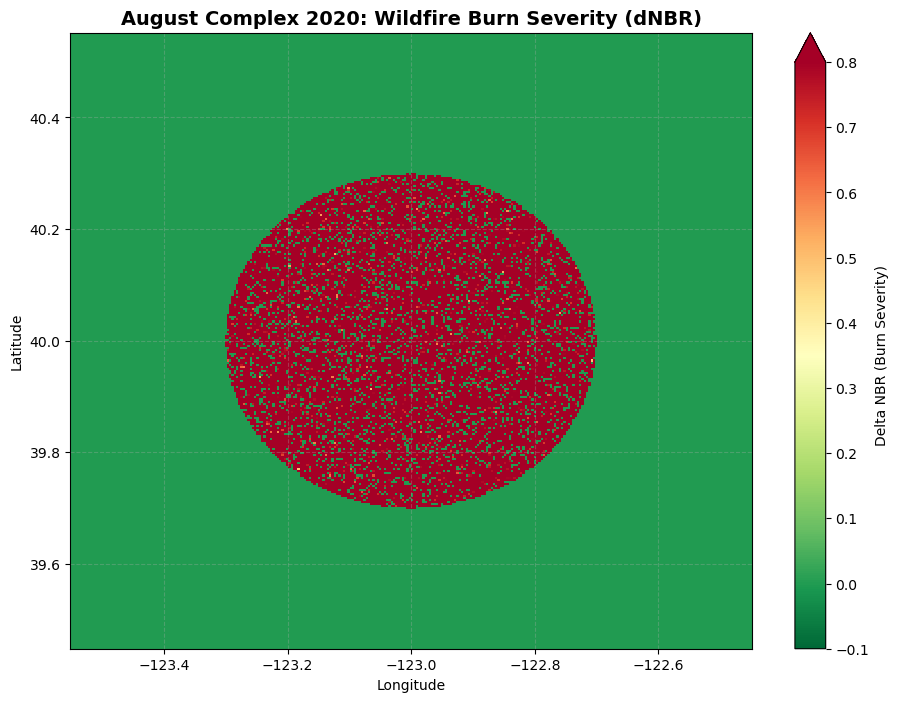

[+] dNBR Calculation and Burn Severity Mapping Successful!


In [11]:
import matplotlib.pyplot as plt

# ==========================================
# 5. Calculate Delta NBR (Burn Severity)
# ==========================================
print("[*] Isolating pre-fire and post-fire time windows...")

# Extract pre-fire (2020-07) and post-fire (2020-10) NBR
nbr_pre = ds["NBR"].sel(time="2020-07-20")
nbr_post = ds["NBR"].sel(time="2020-10-15")

# Calculate Delta NBR (dNBR)
dnbr = nbr_pre - nbr_post

# ==========================================
# 6. Burn Severity Map Visualization
# ==========================================
plt.figure(figsize=(11, 8))
dnbr.plot.imshow(
    cmap="RdYlGn_r",      # Red-Yellow-Green reversed (Red = High dNBR/Severe Burn)
    vmin=-0.1, vmax=0.8,  # Standard USGS dNBR burn severity scale
    cbar_kwargs={'label': 'Delta NBR (Burn Severity)'}
)
plt.title("August Complex 2020: Wildfire Burn Severity (dNBR)", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

print("[+] dNBR Calculation and Burn Severity Mapping Successful!")